# 03. 군집별 특징 추출: 2·3·4번 군집 심층 분석

8개 군집 전체의 특징을 전체 평균과 비교해 정리한 뒤, 특이점이 뚜렷했던 **2번(매너티), 3번(알바트로스), 4번(푸른바다거북)**을 집중적으로 분석했다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common import *
setup_plot()
pd.set_option("display.width", 200)
df = load_data()
pipe = make_pipeline(k=8).fit(df[FEATURES].astype(int))
df["cluster"] = pipe.predict(df[FEATURES].astype(int))
name = lambda c: f"{c} {ANIMALS[c]}"

## 1. 전체 군집 프로파일 (전체 평균 대비 차이)

,평일 여가시간,주말 여가시간,휴식·오락 비율,취미 비율,자기계발 비율,대인관계 비율
0 범고래,-0.6,-1.2,-25.5,14.5,8.2,3.8
1 왜가리,-0.6,-1.1,-1.9,-2.7,-0.8,3.9
2 매너티,0.4,1.0,14.9,-7.6,-4.1,-2.8
3 알바트로스,-1.1,-2.4,-28.9,21.9,4.6,1.9
4 푸른바다거북,0.3,0.4,41.4,-14.9,-9.7,-14.9
5 돌고래,-0.4,-0.5,-10.2,3.2,1.7,4.1
6 펭귄,0.3,0.9,-2.9,-3.7,2.2,4.2
7 해파리,2.3,3.1,33.7,-14.2,-8.1,-10.4


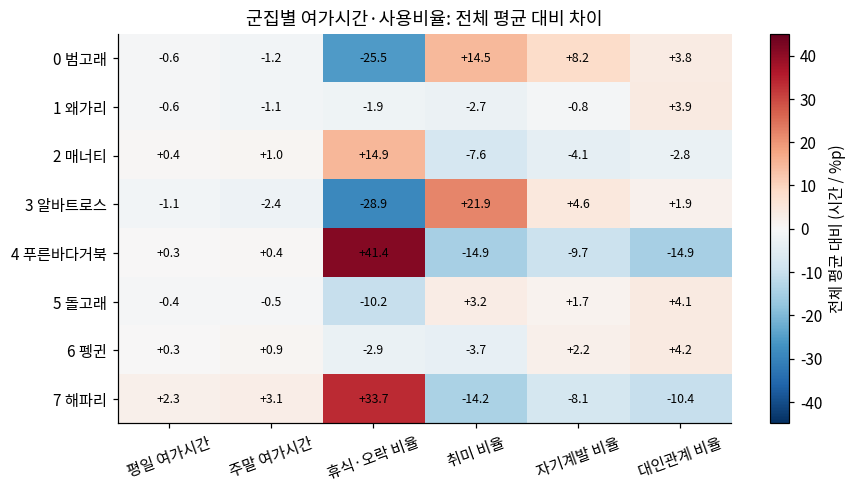

In [2]:
prof = df.groupby("cluster")[RATIO_COLS].mean()
diff = prof - df[RATIO_COLS].mean()
diff.index = [name(c) for c in diff.index]
diff.columns = [FEATURE_KO[c] for c in diff.columns]

fig, ax = plt.subplots(figsize=(9, 4.6))
im = ax.imshow(diff.values, cmap="RdBu_r", vmin=-45, vmax=45, aspect="auto")
ax.set_xticks(range(diff.shape[1]), diff.columns, rotation=20); ax.set_yticks(range(diff.shape[0]), diff.index)
for i in range(diff.shape[0]):
    for j in range(diff.shape[1]):
        ax.text(j, i, f"{diff.values[i, j]:+.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="전체 평균 대비 (시간 / %p)")
ax.set_title("군집별 여가시간·사용비율: 전체 평균 대비 차이")
save(fig, "03_profile_heatmap.png")
diff.round(1)

In [3]:
def share(col, mapping, codes):
    t = pd.crosstab(df["cluster"], df[col], normalize="index") * 100
    overall = df[col].value_counts(normalize=True) * 100
    t.loc["전체"] = overall
    t = t.reindex(columns=codes, fill_value=0)
    t.columns = [mapping[c] for c in codes]
    return t.round(1)

def compare_bar(c, col, mapping, codes, title, fname, ax):
    t = share(col, mapping, codes)
    x = np.arange(len(codes))
    ax.bar(x - .2, t.loc["전체"], .4, label="전체", color="#BAB0AC")
    ax.bar(x + .2, t.loc[c], .4, label=name(c), color="#4C78A8")
    ax.set_xticks(x, t.columns, rotation=35, ha="right"); ax.set_ylabel("%"); ax.set_title(title); ax.legend(fontsize=8)

def deep_dive(c):
    sub = df[df.cluster == c]
    print(f"[{name(c)}] n={len(sub)} ({len(sub)/len(df):.1%})")
    inc = pd.DataFrame({"군집(%)": sub["household_income"].value_counts(normalize=True).sort_index() * 100,
                        "전체(%)": df["household_income"].value_counts(normalize=True).sort_index() * 100}).round(1)
    inc.index = inc.index.map(INCOME)
    print("소득 분포 (전체 대비):"); print(inc.T.to_string())
    print((sub[RATIO_COLS].mean() - df[RATIO_COLS].mean()).rename(FEATURE_KO).round(2).to_string())
    fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
    compare_bar(c, "leisure_purpose", PURPOSE, list(range(1, 10)), "여가목적 1순위", None, axes[0])
    compare_bar(c, "leisure_purpose_2", PURPOSE, list(range(0, 10)), "여가목적 2순위", None, axes[1])
    compare_bar(c, "leisure_activity_1", ACTIVITY, list(range(1, 9)), "관심활동 1순위", None, axes[2])
    compare_bar(c, "leisure_activity_2", ACTIVITY, list(range(0, 9)), "관심활동 2순위", None, axes[3])
    fig.suptitle(f"{name(c)}: 전체 평균과 비교", y=1.02); fig.tight_layout()
    save(fig, f"03_cluster{c}_{ANIMALS[c]}.png")

## 2. Cluster 2 → 매너티: '여유 있는 휴식형'

[2 매너티] n=372 (14.3%)
소득 분포 (전체 대비):
household_income   무응답  300만 미만  300~500만  500~700만  700만 이상
군집(%)             43.8      3.2      15.3      18.5     19.1
전체(%)             40.5      4.2      12.7      19.1     23.5
평일 여가시간      0.38
주말 여가시간      0.96
휴식·오락 비율    14.95
취미 비율       -7.57
자기계발 비율     -4.07
대인관계 비율     -2.82


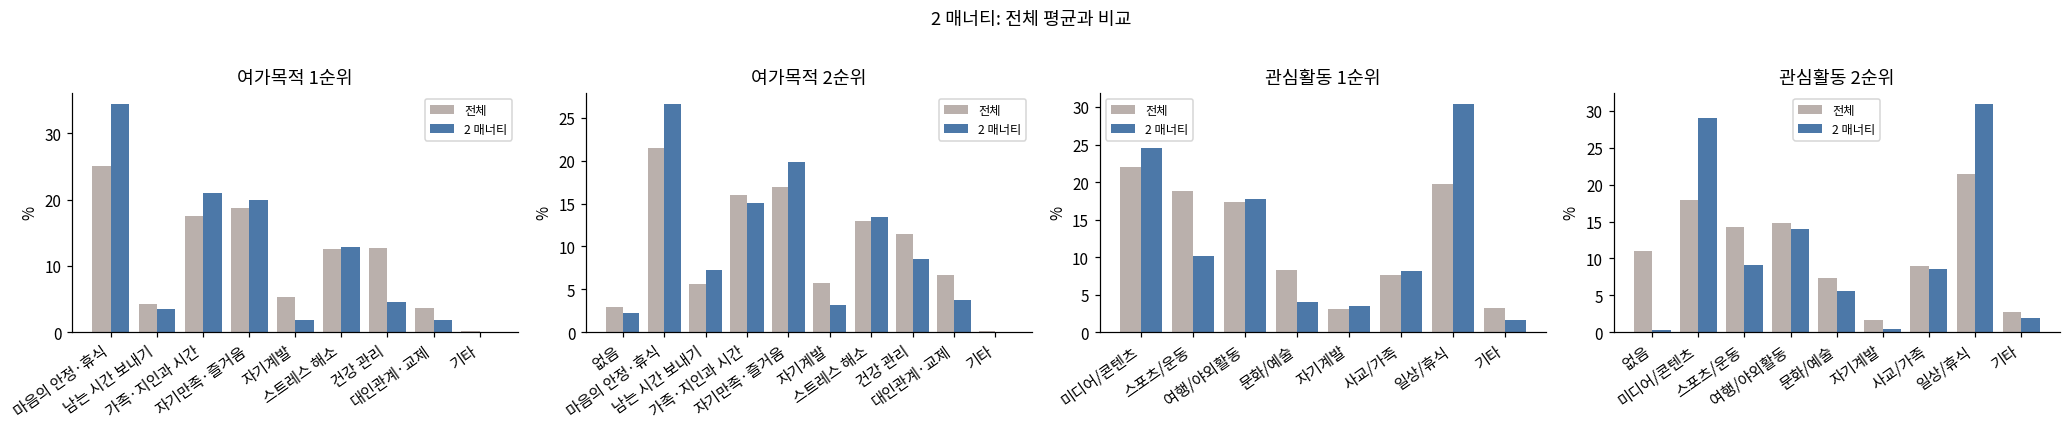

In [4]:
deep_dive(2)

**분석**
- **소득**: 인원수로만 보면 무응답 다음으로 700만 이상(71명) → 500~700만(69명) 순이라 처음에는 '고소득층'으로 해석했다. 하지만 **전체 분포와 비교하면** 700만 이상 비율은 19.1%로 전체(23.5%)보다 오히려 낮다 → 소득은 이 군집을 설명하는 특징이 아니라고 수정했다.
- **여가목적**: 1·2순위 모두 [마음의 안정·휴식]이 전체 평균보다 압도적으로 높고, [건강 관리]는 현저히 낮다 → 건강관리보다 *마음의 여유*를 중시.
- **관심활동**: [일상/휴식] → [미디어/콘텐츠] 순. 3순위부터는 무응답이 급증.
- **여가비율**: 휴식·오락 비율이 전체 평균보다 약 **+15%p**, 나머지 비율은 모두 평균 이하.
- **특이점**: 휴식 중심인데도 **평일·주말 여가시간이 모두 평균 이상**(주말 +1.0시간) → 시간적 여유가 있으면서 그 시간을 휴식으로 채우는 집단.

> 요약: 넉넉한 여가시간을 휴식·오락에 쓰며 마음의 안정을 찾는 유형.

## 3. Cluster 3 → 알바트로스: '짧고 굵은 활동형'

[3 알바트로스] n=240 (9.2%)
소득 분포 (전체 대비):
household_income   무응답  300만 미만  300~500만  500~700만  700만 이상
군집(%)             35.8      2.1      12.9      19.6     29.6
전체(%)             40.5      4.2      12.7      19.1     23.5
평일 여가시간     -1.14
주말 여가시간     -2.38
휴식·오락 비율   -28.90
취미 비율       21.94
자기계발 비율      4.60
대인관계 비율      1.87


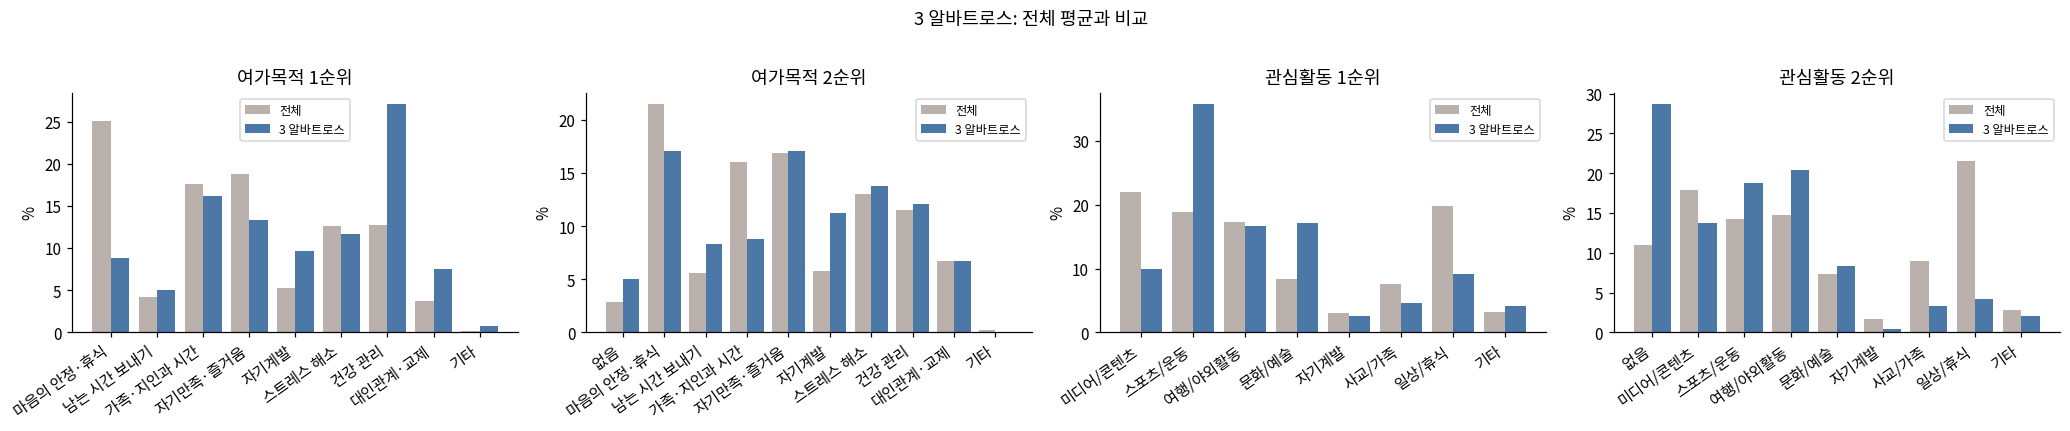

In [5]:
deep_dive(3)

**분석**
- **소득**: 700만 이상 비율 29.6%로 전체(23.5%)보다 높다 → 상대적 고소득층.
- **여가목적**: 1순위에서 [건강 관리]가 전체 평균의 2배 이상(27.1% vs 12.7%), [마음의 안정·휴식]은 현저히 낮음. 1·2순위 모두 [자기계발] 목적도 평균보다 유의미하게 높음.
- **관심활동**: 1순위 [스포츠/운동] **35.8%**로 전체 평균과 압도적 차이. 2순위는 [여행/야외활동]·[스포츠/운동]이 평균보다 5%p 이상 높고, 3순위부터 '없음'이 50% 이상 → 관심사가 활동적인 레저 몇 가지에 집중.
- **여가시간**: 평일 2.1시간, 주말 3.6시간으로 **8개 군집 중 최소**.
- **여가비율**: 휴식·오락 13.3%로 **최소**, 취미 40.8%로 **최대**.

> 요약: 바쁜 생활로 여가시간은 가장 짧지만, 그 시간을 휴식 대신 운동·야외활동 같은 취미에 집중 투자하는 유형.

## 4. Cluster 4 → 푸른바다거북: '휴식 몰입형'

[4 푸른바다거북] n=223 (8.6%)
소득 분포 (전체 대비):
household_income   무응답  300만 미만  300~500만  500~700만  700만 이상
군집(%)             57.4      6.7      13.0      11.7     11.2
전체(%)             40.5      4.2      12.7      19.1     23.5
평일 여가시간      0.26
주말 여가시간      0.45
휴식·오락 비율    41.35
취미 비율      -14.90
자기계발 비율     -9.70
대인관계 비율    -14.87


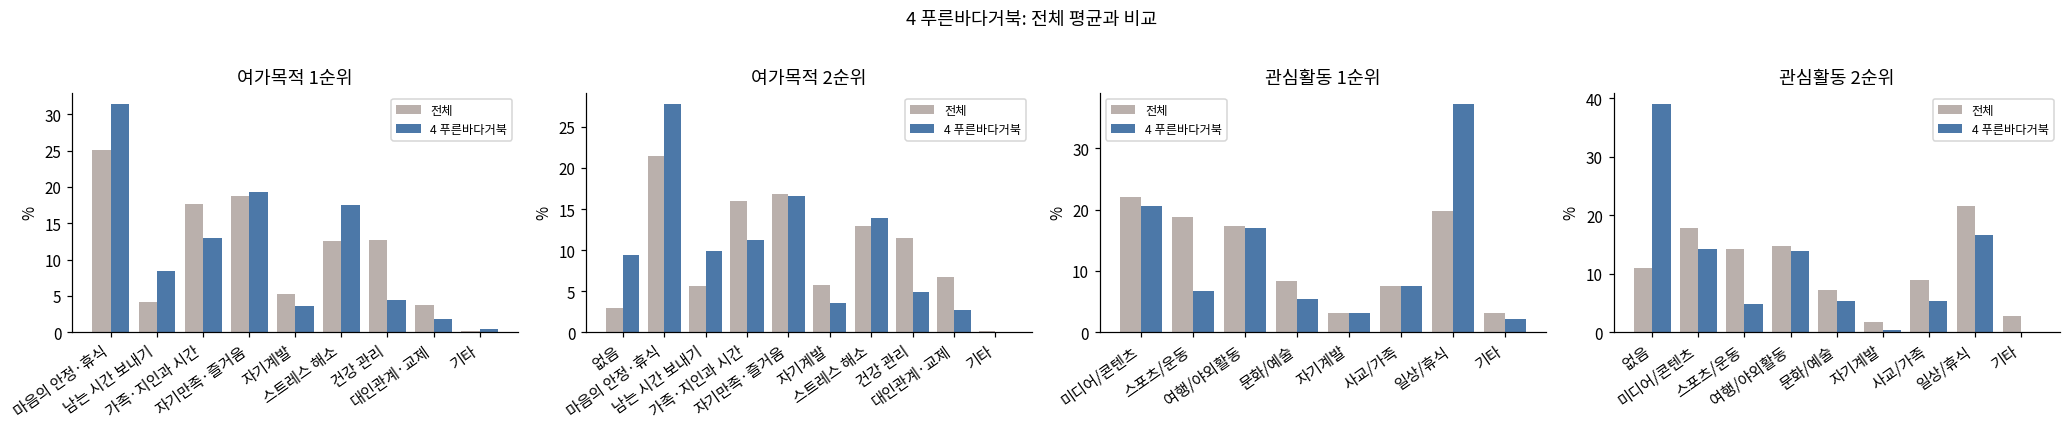

In [6]:
deep_dive(4)

**분석**
- **소득**: 무응답이 57.4%로 가장 많고, 700만 이상 비율은 11.2%로 전체(23.5%)의 절반 수준.
- **여가목적**: [마음의 안정·휴식], [자기만족·즐거움], [스트레스 해소]가 평균보다 높음. 특히 **[남는 시간을 보내기 위해]가 1순위 8.5%, 2순위 9.9%로 전체 평균(4.2%, 5.6%)의 약 2배**. 다른 군집에서는 잘 보이지 않는 목적이다.
- **관심활동**: 1순위 [일상/휴식] → [미디어/콘텐츠] → [여행/야외활동]. 2순위는 39%가 '없음', 3순위부터 62.3%가 무응답 → 관심 활동의 폭이 좁음.
- **여가시간**: 평일·주말 모두 전체 평균과 거의 같음(+0.2시간 내외).
- **여가비율**: 휴식·오락 **83.6%로 최대**(평균 대비 약 +41%p), 취미·자기계발·대인관계는 모두 **최소**.

> 요약: 2번(매너티)과 같은 휴식 지향이지만, 관심 활동의 폭이 좁고 교제 비율이 최소로, 여가시간 대부분을 혼자만의 휴식·오락으로 보내는 유형.

## 5. 2번 vs 4번: 같은 '휴식형'을 어떻게 구분했나

In [7]:
cmp = df[df.cluster.isin([2, 4, 7])].groupby("cluster")[RATIO_COLS].mean().round(1)
cmp["700만 이상 비율(%)"] = df[df.cluster.isin([2, 4, 7])].groupby("cluster")["household_income"].apply(lambda s: (s == 4).mean() * 100).round(1)
cmp["'남는 시간' 목적(%)"] = df[df.cluster.isin([2, 4, 7])].groupby("cluster")["leisure_purpose"].apply(lambda s: (s == 2).mean() * 100).round(1)
cmp.index = [name(c) for c in cmp.index]
cmp.rename(columns=FEATURE_KO)

,평일 여가시간,주말 여가시간,휴식·오락 비율,취미 비율,자기계발 비율,대인관계 비율,700만 이상 비율(%),'남는 시간' 목적(%)
2 매너티,3.6,6.9,57.2,11.3,9.1,20.4,19.1,3.5
4 푸른바다거북,3.5,6.4,83.6,4.0,3.4,8.3,11.2,8.5
7 해파리,5.5,9.1,75.9,4.7,5.1,12.8,11.8,11.4


휴식·오락 비율이 높은 세 군집은 **소득, 여가시간의 양, 교제 비율, 여가 목적**으로 구분된다.
- **매너티(2)**: 휴식 비율 57%로 '적당히' 높고 교제·취미도 어느 정도 유지 + 마음의 안정이 목적
- **푸른바다거북(4)**: 휴식 비율 84%로 극단적 + 교제 비율 최소(8.3%) + '남는 시간' 목적이 두드러짐
- **해파리(7)**: 여가시간 최대(평일 5.5h / 주말 9.1h) + 미디어/콘텐츠 중심

02 노트북의 교차표를 보면 푸른바다거북은 k=6에서도 거의 그대로(223명 중 220명) 유지되는 **안정적인 군집**이고, 매너티는 k=6에서 돌고래와 섞여 있다가 k=8에서 분리된다.